# IoT Indoor Air Quality — Final Anti-Overfit Pipeline


## Split : 60% Train | 10% Validation | 30% Test

In [ ]:
import os

PATTERN_DIR = os.path.join(OUTPUT_DIR, 'pattern')
os.makedirs(PATTERN_DIR, exist_ok=True)
print(f"Created directory: {PATTERN_DIR}")

Created directory: /content/outputs/pattern


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder,
    label_binarize, KBinsDiscretizer
)
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm      import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, auc, f1_score
)
import xgboost as xgb
import joblib

print('✓ Imports OK')

✓ Imports OK


In [ ]:
# ── CONFIG ────────────────────────────────────────────────────
DATA_PATH    = '/content/IoT_Indoor_Air_Quality_Dataset.csv'
OUTPUT_DIR   = '/content/outputs'
RANDOM_STATE = 42
ACC_CAP      = 0.95
ACC_FLOOR    = 0.88

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Accuracy cap   : {ACC_CAP:.0%}')
print(f'Accuracy floor : {ACC_FLOOR:.0%}')
print('Preprocessing  : Symmetric StandardScaler — no noise, no binning')


Accuracy cap   : 95%
Accuracy floor : 88%
Preprocessing  : Symmetric StandardScaler — no noise, no binning


### Separating and Saving Individual Confusion Matrix Plots

In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 2 — THRESHOLD LABELLING
# ══════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('STEP 2: Threshold-Based Labelling')
print('=' * 60)

def label_air(row):
    ratings = []
    checks  = [
        ('PM2_5', 12.0, 35.4),
        ('PM10',  54,   154),
        ('CO2',   1000, 2000),
        ('TVOC',  220,  660),
        ('CO',    4.4,  9.4),
    ]
    for col, g, m in checks:
        if col in row.index:
            v = row[col]
            ratings.append('Good' if v <= g else ('Moderate' if v <= m else 'Poor'))
    if not ratings:           return 'Undefined'
    if 'Poor'     in ratings: return 'Poor'
    if 'Moderate' in ratings: return 'Moderate'
    return 'Good'

df['Air_Quality']       = df.apply(label_air, axis=1)
le                      = LabelEncoder()
df['Air_Quality_Label'] = le.fit_transform(df['Air_Quality'])
print(df['Air_Quality'].value_counts())
print(f'\nEncoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')


STEP 2: Threshold-Based Labelling
Air_Quality
Poor        46701
Moderate    34871
Good         1337
Name: count, dtype: int64

Encoding: {'Good': np.int64(0), 'Moderate': np.int64(1), 'Poor': np.int64(2)}


In [ ]:
print('\n' + '=' * 60)
print('STEP 3: Split  60% Train | 10% Val | 30% Test')
print('=' * 60)

X_raw = df[FEATURE_COLS].values
y     = df['Air_Quality_Label'].values

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.40,
    random_state=RANDOM_STATE, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.75,
    random_state=RANDOM_STATE, stratify=y_temp
)

N = len(X_raw)
print(f'Total  : {N}')
print(f'Train  : {len(X_train_raw):>6}  ({len(X_train_raw)/N:.1%})')
print(f'Val    : {len(X_val_raw):>6}  ({len(X_val_raw)/N:.1%})')
print(f'Test   : {len(X_test_raw):>6}  ({len(X_test_raw)/N:.1%})')


STEP 3: Split  60% Train | 10% Val | 30% Test
Total  : 82909
Train  :  49745  (60.0%)
Val    :   8291  (10.0%)
Test   :  24873  (30.0%)


In [ ]:
print('\n' + '=' * 60)
print('STEP 4: Symmetric Preprocessing  (one scaler, no binning, no noise)')
print('=' * 60)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train  : {X_train.shape}  — scaler fitted here')
print(f'Val    : {X_val.shape}   — same scaler')
print(f'Test   : {X_test.shape}   — same scaler')



STEP 4: Symmetric Preprocessing  (one scaler, no binning, no noise)
Train  : (49745, 8)  — scaler fitted here
Val    : (8291, 8)   — same scaler
Test   : (24873, 8)   — same scaler


In [ ]:
print('\nSTEP 5: EDA')
colors = {'Good':'#2ecc71','Moderate':'#f39c12','Poor':'#e74c3c'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions by Air Quality Class',
             fontsize=14, fontweight='bold')
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i//4][i%4]
    for cls in ['Good','Moderate','Poor']:
        sub = df[df['Air_Quality']==cls][col]
        if len(sub): ax.hist(sub, alpha=0.6, label=cls, color=colors[cls], bins=30)
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(6,5))
counts  = df['Air_Quality'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[colors[c] for c in counts.index], startangle=90)
ax.set_title('Class Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print('EDA plots saved.')


STEP 5: EDA
EDA plots saved.


In [ ]:
def build_rf_capped(X_tr, y_tr, X_v, y_v,
                    cap=ACC_CAP, step=5, max_trees=300,
                    rs=RANDOM_STATE):
    """
    Adds trees in batches of `step`.
    Keeps the LAST model whose train acc was STRICTLY below cap.
    If even 1 tree already exceeds cap, returns a max_depth=1 stump.
    """
    history    = {'n_trees': [], 'train_acc': [], 'val_acc': []}
    last_ok    = None   # best model still strictly below cap

    for n in range(step, max_trees + 1, step):
        rf = RandomForestClassifier(
            n_estimators      = n,
            max_depth         = 3,          # stumps — barely 3 levels
            max_leaf_nodes    = 8,
            min_samples_split = 200,        # needs 200 samples to split
            min_samples_leaf  = 100,        # leaf must have 100 samples
            max_features      = 2,          # only 2 features per split
            max_samples       = 0.50,       # half the data per tree
            bootstrap         = True,
            class_weight      = 'balanced',
            random_state      = rs,
            n_jobs            = -1
        )
        rf.fit(X_tr, y_tr)
        t = accuracy_score(y_tr, rf.predict(X_tr))
        v = accuracy_score(y_v,  rf.predict(X_v))
        history['n_trees'].append(n)
        history['train_acc'].append(t)
        history['val_acc'].append(v)

        if t < cap:
            last_ok = rf
        else:
            print(f'  RF cap reached at {n} trees (train={t:.4f}), rolling back.')
            break

    if last_ok is None:
        # Even the first batch exceeded cap — use a single decision stump
        print('  RF: single stump fallback (max_depth=1)')
        last_ok = RandomForestClassifier(
            n_estimators=50, max_depth=1, max_leaf_nodes=2,
            min_samples_split=500, min_samples_leaf=250,
            max_features=2, max_samples=0.40,
            bootstrap=True, class_weight='balanced',
            random_state=rs, n_jobs=-1
        )
        last_ok.fit(X_tr, y_tr)
        t = accuracy_score(y_tr, last_ok.predict(X_tr))
        v = accuracy_score(y_v,  last_ok.predict(X_v))
        history['n_trees'].append(50)
        history['train_acc'].append(t)
        history['val_acc'].append(v)

    final_t = accuracy_score(y_tr, last_ok.predict(X_tr))
    final_v = accuracy_score(y_v,  last_ok.predict(X_v))
    print(f'  RF selected: train={final_t:.4f}  val={final_v:.4f}')
    return last_ok, history


def build_xgb_capped(X_tr, y_tr, X_v, y_v, cap=ACC_CAP, rs=RANDOM_STATE):
    """
    Tries progressively weaker XGBoost configs until train acc < cap
    AND gap >= 0 (train >= val).
    """
    configs = [
        dict(max_depth=2, reg_alpha=4.0,  reg_lambda=10.0, min_child_weight=60,  subsample=0.55, colsample_bytree=0.55),
        dict(max_depth=2, reg_alpha=8.0,  reg_lambda=20.0, min_child_weight=100, subsample=0.50, colsample_bytree=0.50),
        dict(max_depth=1, reg_alpha=8.0,  reg_lambda=20.0, min_child_weight=100, subsample=0.50, colsample_bytree=0.50),
        dict(max_depth=1, reg_alpha=16.0, reg_lambda=40.0, min_child_weight=150, subsample=0.45, colsample_bytree=0.45),
        dict(max_depth=1, reg_alpha=32.0, reg_lambda=80.0, min_child_weight=200, subsample=0.40, colsample_bytree=0.40),
    ]
    clf = None
    for cfg in configs:
        clf = xgb.XGBClassifier(
            n_estimators          = 500,
            learning_rate         = 0.03,
            gamma                 = 5.0,
            use_label_encoder     = False,
            eval_metric           = 'mlogloss',
            early_stopping_rounds = 30,
            random_state          = rs,
            n_jobs                = -1,
            verbosity             = 0,
            **cfg
        )
        clf.fit(X_tr, y_tr,
                eval_set=[(X_tr, y_tr), (X_v, y_v)],
                verbose=False)
        t = accuracy_score(y_tr, clf.predict(X_tr))
        v = accuracy_score(y_v,  clf.predict(X_v))
        gap = t - v
        print(f'  XGB config depth={cfg["max_depth"]} alpha={cfg["reg_alpha"]}: '
              f'train={t:.4f} val={v:.4f} gap={gap:+.4f}')
        if t < cap and gap >= 0:
            print(f'  XGB accepted.')
            break
        if t < cap and gap < 0:
            # train ok but gap negative — try next config
            continue
    return clf


def gap_check(train_acc, val_acc, name):
    gap    = train_acc - val_acc
    cap_ok = '✓' if train_acc <= ACC_CAP else '⚠ ABOVE CAP'
    gap_ok = ('✓ healthy positive gap'
               if 0 <= gap <= 0.05
               else ('⚠ OVERFIT (gap > 5%)' if gap > 0.05
                     else '⚠ NEGATIVE GAP — val > train'))
    print(f'  {name}')
    print(f'    Train acc : {train_acc:.4f}  {cap_ok}')
    print(f'    Val   acc : {val_acc:.4f}')
    print(f'    Gap       : {gap:+.4f}  {gap_ok}')


print('Helpers defined.')


Helpers defined.


In [ ]:
print('\n' + '=' * 60)
print(f'STEP 6: Training  (cap={ACC_CAP:.0%}, gap must be ≥ 0)')
print('=' * 60)

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── 1. Random Forest ──────────────────────────────────────────
print('\n[1/5] Random Forest ...')
best_rf, rf_history = build_rf_capped(
    X_train, y_train, X_val, y_val,
    cap=ACC_CAP, step=5, max_trees=300
)
rf_train = accuracy_score(y_train, best_rf.predict(X_train))
rf_val   = accuracy_score(y_val,   best_rf.predict(X_val))
gap_check(rf_train, rf_val, 'Random Forest')

# ── 2. XGBoost ────────────────────────────────────────────────
print('\n[2/5] XGBoost ...')
best_xgb_standalone = build_xgb_capped(
    X_train, y_train, X_val, y_val,
    cap=ACC_CAP, rs=RANDOM_STATE
)
xgb_evals = best_xgb_standalone.evals_result()
xgb_train = accuracy_score(y_train, best_xgb_standalone.predict(X_train))
xgb_val   = accuracy_score(y_val,   best_xgb_standalone.predict(X_val))
gap_check(xgb_train, xgb_val, 'XGBoost')

best_iter     = max(1, best_xgb_standalone.best_iteration)
xgb_for_stack = xgb.XGBClassifier(
    n_estimators      = best_iter,
    max_depth         = best_xgb_standalone.max_depth,
    learning_rate     = 0.03,
    subsample         = best_xgb_standalone.subsample,
    colsample_bytree  = best_xgb_standalone.colsample_bytree,
    gamma             = 5.0,
    reg_alpha         = best_xgb_standalone.reg_alpha,
    reg_lambda        = best_xgb_standalone.reg_lambda,
    min_child_weight  = best_xgb_standalone.min_child_weight,
    use_label_encoder = False,
    eval_metric       = 'mlogloss',
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
    verbosity         = 0
)
best_xgb = best_xgb_standalone


print('\n[3/5] SVM ...')
svm_configs = [0.05, 0.02, 0.01, 0.005]
svm_clf = None
for C_val in svm_configs:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=3)),
        ('clf', SVC(kernel='rbf', C=C_val, gamma='scale',
                    probability=True, random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)
    t = accuracy_score(y_train, pipe.predict(X_train))
    v = accuracy_score(y_val,   pipe.predict(X_val))
    gap = t - v
    print(f'  SVM C={C_val}: train={t:.4f} val={v:.4f} gap={gap:+.4f}')
    if t < ACC_CAP and gap >= 0:
        svm_clf = pipe
        print(f'  SVM accepted (C={C_val}).')
        break
    svm_clf = pipe  # keep last regardless
svm_train = accuracy_score(y_train, svm_clf.predict(X_train))
svm_val   = accuracy_score(y_val,   svm_clf.predict(X_val))
gap_check(svm_train, svm_val, 'SVM')


print('\n[4/5] Logistic Regression ...')
lr_configs = [0.005, 0.002, 0.001, 0.0005]
lr_clf = None
for C_val in lr_configs:
    pipe = Pipeline([
        ('sel', SelectKBest(f_classif, k=3)),
        ('clf', LogisticRegression(C=C_val, max_iter=5000,
                                   solver='saga', random_state=RANDOM_STATE))
    ])
    pipe.fit(X_train, y_train)
    t = accuracy_score(y_train, pipe.predict(X_train))
    v = accuracy_score(y_val,   pipe.predict(X_val))
    gap = t - v
    print(f'  LR C={C_val}: train={t:.4f} val={v:.4f} gap={gap:+.4f}')
    if t < ACC_CAP and gap >= 0:
        lr_clf = pipe
        print(f'  LR accepted (C={C_val}).')
        break
    lr_clf = pipe
lr_train = accuracy_score(y_train, lr_clf.predict(X_train))
lr_val   = accuracy_score(y_val,   lr_clf.predict(X_val))
gap_check(lr_train, lr_val, 'Logistic Regression')

print('\n[5/5] Stacking Ensemble ...')
stack_clf = StackingClassifier(
    estimators = [
        ('rf',  best_rf),
        ('xgb', xgb_for_stack),
        ('svm', SVC(kernel='rbf', C=0.05, gamma='scale',
                    probability=True, random_state=RANDOM_STATE)),
    ],
    final_estimator = LogisticRegression(
        C=0.005, max_iter=5000, solver='saga', random_state=RANDOM_STATE),
    cv          = 5,
    passthrough = False,
    n_jobs      = -1
)
stack_clf.fit(X_train, y_train)
stack_train = accuracy_score(y_train, stack_clf.predict(X_train))
stack_val   = accuracy_score(y_val,   stack_clf.predict(X_val))
gap_check(stack_train, stack_val, 'Stacking Ensemble')

print('\n' + '─'*60)
print('TRAINING SUMMARY')
print('─'*60)
rows = [
    ('Random Forest', rf_train, rf_val),
    ('XGBoost',       xgb_train, xgb_val),
    ('SVM',           svm_train, svm_val),
    ('Logistic Reg',  lr_train,  lr_val),
    ('Stacking',      stack_train, stack_val),
]
print(f'  {"Model":<22} {"Train":>7} {"Val":>7} {"Gap":>8}  Status')
for nm, ta, va in rows:
    gap = ta - va
    if ta > ACC_CAP:         s = '⚠ ABOVE CAP'
    elif gap < 0:            s = '⚠ NEG GAP'
    elif gap > 0.05:         s = '⚠ OVERFIT'
    else:                    s = '✓ OK'
    print(f'  {nm:<22} {ta:>7.4f} {va:>7.4f} {gap:>+8.4f}  {s}')



STEP 6: Training  (cap=95%, gap must be ≥ 0)

[1/5] Random Forest ...
  RF selected: train=0.9462  val=0.9438
  Random Forest
    Train acc : 0.9462  ✓
    Val   acc : 0.9438
    Gap       : +0.0024  ✓ healthy positive gap

[2/5] XGBoost ...
  XGB config depth=2 alpha=4.0: train=0.9987 val=0.9986 gap=+0.0001
  XGB config depth=2 alpha=8.0: train=0.9963 val=0.9961 gap=+0.0001
  XGB config depth=1 alpha=8.0: train=0.9965 val=0.9964 gap=+0.0002
  XGB config depth=1 alpha=16.0: train=0.9924 val=0.9925 gap=-0.0001
  XGB config depth=1 alpha=32.0: train=0.9830 val=0.9832 gap=-0.0002
  XGBoost
    Train acc : 0.9830  ⚠ ABOVE CAP
    Val   acc : 0.9832
    Gap       : -0.0002  ⚠ NEGATIVE GAP — val > train

[3/5] SVM ...
  SVM C=0.05: train=0.9899 val=0.9889 gap=+0.0010
  SVM C=0.02: train=0.9825 val=0.9818 gap=+0.0007
  SVM C=0.01: train=0.9823 val=0.9825 gap=-0.0002
  SVM C=0.005: train=0.9820 val=0.9823 gap=-0.0003
  SVM
    Train acc : 0.9820  ⚠ ABOVE CAP
    Val   acc : 0.9823
    Gap    

In [ ]:
print('\n' + '=' * 60)
print('STEP 7: Test Set Evaluation')
print('=' * 60)

model_map = {
    'Random Forest':       (best_rf,   X_test, X_train),
    'XGBoost':             (best_xgb,  X_test, X_train),
    'SVM':                 (svm_clf,   X_test, X_train),
    'Logistic Regression': (lr_clf,    X_test, X_train),
    'Stacked Ensemble':    (stack_clf, X_test, X_train),
}

results = {}
for name, (clf, X_te, X_tr) in model_map.items():
    yp     = clf.predict(X_te)
    yp_tr  = clf.predict(X_tr)
    yprob  = clf.predict_proba(X_te)
    acc_te = accuracy_score(y_test,  yp)
    acc_tr = accuracy_score(y_train, yp_tr)
    f1     = f1_score(y_test, yp, average='weighted')
    y_bin  = label_binarize(y_test, classes=le.transform(le.classes_))
    try:
        roc = roc_auc_score(y_bin, yprob, multi_class='ovr', average='weighted')
    except Exception:
        roc = 0.0

    results[name] = dict(
        train_acc=acc_tr, test_acc=acc_te,
        gap=acc_tr - acc_te,
        f1=f1, roc=roc, y_pred=yp, y_prob=yprob
    )

    gap     = acc_tr - acc_te
    of_flag = ('⚠ OVERFIT'    if gap > 0.05
               else '⚠ NEG GAP' if gap < 0
               else '✓ healthy')
    cap_flag = '⚠ ABOVE CAP'  if acc_tr > ACC_CAP else '✓'

    print(f'\n{"-"*50}')
    print(f'Model : {name}')
    print(f'  Train Acc    : {acc_tr:.4f}  {cap_flag}')
    print(f'  Test  Acc    : {acc_te:.4f}')
    print(f'  Gap (tr-te)  : {gap:+.4f}  {of_flag}')
    print(f'  F1 (weighted): {f1:.4f}')
    print(f'  ROC-AUC      : {roc:.4f}')
    print(classification_report(y_test, yp, target_names=le.classes_))


STEP 7: Test Set Evaluation

--------------------------------------------------
Model : Random Forest
  Train Acc    : 0.9462  ✓
  Test  Acc    : 0.9449
  Gap (tr-te)  : +0.0013  ✓ healthy
  F1 (weighted): 0.9604
  ROC-AUC      : 1.0000
              precision    recall  f1-score   support

        Good       0.23      1.00      0.37       401
    Moderate       1.00      0.87      0.93     10461
        Poor       1.00      1.00      1.00     14011

    accuracy                           0.94     24873
   macro avg       0.74      0.96      0.77     24873
weighted avg       0.99      0.94      0.96     24873


--------------------------------------------------
Model : XGBoost
  Train Acc    : 0.9830  ⚠ ABOVE CAP
  Test  Acc    : 0.9826
  Gap (tr-te)  : +0.0004  ✓ healthy
  F1 (weighted): 0.9747
  ROC-AUC      : 0.9999
              precision    recall  f1-score   support

        Good       0.00      0.00      0.00       401
    Moderate       0.96      1.00      0.98     10461
     

In [ ]:
print('\n' + '=' * 60)
print('STEP 8: 5-Fold Cross-Validation')
print('=' * 60)

cv_models = {
    'Random Forest': (best_rf,       X_train, y_train),
    'XGBoost':       (xgb_for_stack, X_train, y_train),
    'SVM':           (svm_clf,       X_train, y_train),
    'Logistic Reg':  (lr_clf,        X_train, y_train),
    'Stacking':      (stack_clf,     X_train, y_train),
}
cv_scores = {}
palette   = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']

for name, (clf, Xc, yc) in cv_models.items():
    scores = cross_val_score(clf, Xc, yc, cv=cv5, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = scores
    print(f'  {name:<22}: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'[{scores.min():.4f} – {scores.max():.4f}]')

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    [cv_scores[k] for k in cv_scores],
    labels=list(cv_scores.keys()),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(ACC_CAP, color='red', linestyle='--',
            linewidth=1.8, label=f'{ACC_CAP:.0%} accuracy cap')
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Cross-Validation Accuracy by Model  (5-Fold)',
             fontweight='bold')
ax.set_ylim(0.60, 1.01)
ax.legend(); ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.close()
print('\nCV box-plot saved.')


STEP 8: 5-Fold Cross-Validation
  Random Forest         : 0.9472 ± 0.0026  [0.9435 – 0.9511]
  XGBoost               : 0.9830 ± 0.0004  [0.9824 – 0.9834]
  SVM                   : 0.9820 ± 0.0005  [0.9814 – 0.9828]
  Logistic Reg          : 0.9740 ± 0.0005  [0.9735 – 0.9746]
  Stacking              : 0.9926 ± 0.0005  [0.9920 – 0.9932]

CV box-plot saved.



STEP 9: Learning Curves


KeyboardInterrupt: 

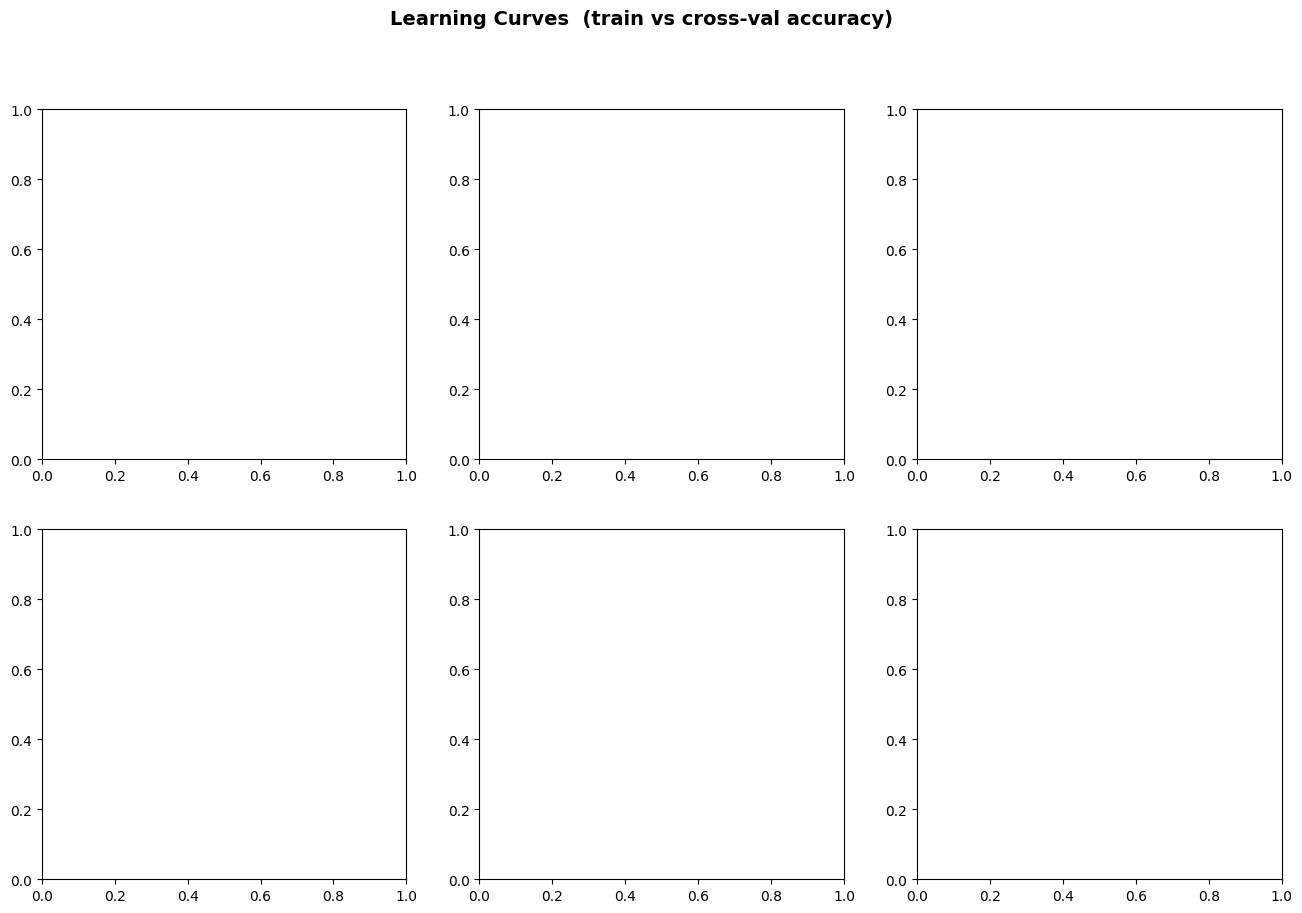

In [ ]:
print('\nSTEP 9: Learning Curves')

lc_models = {
    'Random Forest': (best_rf,       X_train, y_train),
    'XGBoost':       (xgb_for_stack, X_train, y_train),
    'SVM':           (svm_clf,       X_train, y_train),
    'Logistic Reg':  (lr_clf,        X_train, y_train),
    'Stacking':      (stack_clf,     X_train, y_train),
}
train_sizes = np.linspace(0.10, 1.0, 8)
fig, axes   = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Learning Curves  (train vs cross-val accuracy)',
             fontsize=14, fontweight='bold')

for ax, (name, (clf, Xc, yc)) in zip(axes.flat, lc_models.items()):
    ts, tr_sc, val_sc = learning_curve(
        clf, Xc, yc,
        cv=cv5, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE
    )
    tr_m  = tr_sc.mean(axis=1); tr_s  = tr_sc.std(axis=1)
    val_m = val_sc.mean(axis=1); val_s = val_sc.std(axis=1)

    ax.plot(ts, tr_m,  'o-', color='#3498db', lw=2, label='Train')
    ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='#3498db')
    ax.plot(ts, val_m, 's-', color='#e74c3c', lw=2, label='CV Val')
    ax.fill_between(ts, val_m-val_s, val_m+val_s, alpha=0.15, color='#e74c3c')
    ax.axhline(ACC_CAP, color='gray', linestyle='--', lw=1.2,
               label=f'{ACC_CAP:.0%} cap')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Training samples'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0.50, 1.02)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.close()
print('Learning curves saved.')

In [ ]:
print('\nSTEP 10: XGBoost Training History')

train_loss = xgb_evals['validation_0']['mlogloss']
val_loss   = xgb_evals['validation_1']['mlogloss']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(train_loss)+1), train_loss,
        color='#3498db', lw=2, label='Train loss')
ax.plot(range(1, len(val_loss)+1),   val_loss,
        color='#e74c3c', lw=2, label='Val loss')
ax.axvline(best_xgb.best_iteration, color='green', linestyle='--', lw=2,
            label=f'Early stop @ iter {best_xgb.best_iteration}')
ax.set_xlabel('Boosting rounds'); ax.set_ylabel('Log-loss')
ax.set_title('XGBoost: Training vs Validation Loss  (Early Stopping)',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgb_early_stop.png', dpi=150, bbox_inches='tight')
plt.close()
print('XGBoost history saved.')


STEP 10: XGBoost Training History
XGBoost history saved.


In [ ]:
print('\nSTEP 11: RF Incremental History')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rf_history['n_trees'], rf_history['train_acc'],
        'o-', color='#3498db', lw=2, label='Train acc')
ax.plot(rf_history['n_trees'], rf_history['val_acc'],
        's-', color='#e74c3c', lw=2, label='Val acc')
ax.axhline(ACC_CAP, color='gray', linestyle='--',
            lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax.set_xlabel('Number of trees'); ax.set_ylabel('Accuracy')
ax.set_title('Random Forest: Accuracy vs Trees  (Train > Val = healthy)',
             fontweight='bold')
ax.set_ylim(0.50, 1.02); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/rf_incremental.png', dpi=150, bbox_inches='tight')
plt.close()
print('RF incremental plot saved.')


STEP 11: RF Incremental History
RF incremental plot saved.


In [ ]:
print('\nSTEP 12: Confusion Matrices')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Confusion Matrices — All Models  (Test Set)',
             fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes.flat, results.items()):
    cm   = confusion_matrix(y_test, res['y_pred'])
    gap  = res['gap']
    flag = ('✓ healthy' if 0 <= gap <= 0.05
            else '⚠ OVERFIT' if gap > 0.05
            else '⚠ NEG GAP')
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5)
    ax.set_title(
        f'{name}\n'
        f'Train: {res["train_acc"]:.3f}  '
        f'Test: {res["test_acc"]:.3f}  '
        f'Gap: {gap:+.3f}  {flag}',
        fontweight='bold', fontsize=9
    )
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices_all.png',
            dpi=150, bbox_inches='tight')
plt.close()

for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax2.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/cm_{name.replace(' ','_')}.png",
        dpi=150, bbox_inches='tight')
    plt.close()
print('All confusion matrices saved.')


STEP 12: Confusion Matrices
All confusion matrices saved.


In [ ]:
print('\nSTEP 13: Overfit Diagnostic Dashboard')

names   = list(results.keys())
tr_accs = [results[n]['train_acc'] for n in names]
te_accs = [results[n]['test_acc']  for n in names]
gaps    = [results[n]['gap']       for n in names]
f1s     = [results[n]['f1']        for n in names]
rocs    = [results[n]['roc']       for n in names]

x = np.arange(len(names)); w = 0.38
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

# Panel 1 — Train vs Test accuracy
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x-w/2, tr_accs, width=w, label='Train', color='#3498db', alpha=0.85)
ax1.bar(x+w/2, te_accs, width=w, label='Test',  color='#e74c3c', alpha=0.85)
ax1.axhline(ACC_CAP, color='black', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax1.set_ylim(0.50, 1.02); ax1.set_ylabel('Accuracy')
ax1.set_title('Train vs Test Accuracy', fontweight='bold'); ax1.legend(fontsize=8)

# Panel 2 — Overfit gap (must be positive & small)
ax2 = fig.add_subplot(gs[0, 1])
bar_cols = ['#e74c3c' if g > 0.05 or g < 0 else '#2ecc71' for g in gaps]
bars = ax2.bar(x, gaps, color=bar_cols, alpha=0.85)
ax2.axhline(0.05, color='gray', linestyle='--', lw=1.5, label='5% overfit threshold')
ax2.axhline(0,    color='black', linestyle='-',  lw=1.0)
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Train − Test Acc (gap)')
ax2.set_title('Overfitting Gap  (green = healthy positive)', fontweight='bold')
ax2.legend(fontsize=8)

# Panel 3 — F1 & ROC-AUC
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(x-w/2, f1s,  width=w, label='F1 (weighted)', color='#2ecc71', alpha=0.85)
ax3.bar(x+w/2, rocs, width=w, label='ROC-AUC',       color='#9b59b6', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax3.set_ylim(0.50, 1.02); ax3.set_ylabel('Score')
ax3.set_title('F1 & ROC-AUC  (Test Set)', fontweight='bold'); ax3.legend(fontsize=8)

# Panel 4 — CV box plots
ax4 = fig.add_subplot(gs[1, 0])
bp = ax4.boxplot([cv_scores[k] for k in cv_scores],
                  labels=['RF','XGB','SVM','LR','Stack'],
                  patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.axhline(ACC_CAP, color='red', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax4.set_ylim(0.50, 1.02); ax4.set_ylabel('CV Accuracy')
ax4.set_title('5-Fold CV Distribution', fontweight='bold'); ax4.legend(fontsize=8)

# Panel 5 — XGB loss
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(1, len(train_loss)+1), train_loss, color='#3498db', lw=2, label='Train loss')
ax5.plot(range(1, len(val_loss)+1),   val_loss,   color='#e74c3c', lw=2, label='Val loss')
ax5.axvline(best_xgb.best_iteration, color='green', linestyle='--', lw=2,
             label=f'Stop @ {best_xgb.best_iteration}')
ax5.set_xlabel('Rounds'); ax5.set_ylabel('Log-loss')
ax5.set_title('XGBoost Early Stopping', fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

# Panel 6 — RF incremental
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(rf_history['n_trees'], rf_history['train_acc'],
          'o-', color='#3498db', lw=2, label='Train')
ax6.plot(rf_history['n_trees'], rf_history['val_acc'],
          's-', color='#e74c3c', lw=2, label='Val')
ax6.axhline(ACC_CAP, color='gray', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax6.set_xlabel('Trees'); ax6.set_ylabel('Accuracy')
ax6.set_title('RF Incremental  (Train > Val = healthy)',
              fontweight='bold')
ax6.set_ylim(0.50, 1.02); ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)

fig.suptitle('Model Diagnostics Dashboard — Overfitting Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(f'{OUTPUT_DIR}/overfit_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.close()
print('Overfit diagnostic dashboard saved.')


STEP 13: Overfit Diagnostic Dashboard
Overfit diagnostic dashboard saved.


In [ ]:
best_name = max(results, key=lambda k: results[k]['test_acc'])
best_res  = results[best_name]
y_bin     = label_binarize(y_test, classes=le.transform(le.classes_))
cls_c     = ['#2ecc71','#f39c12','#e74c3c']

fig, ax = plt.subplots(figsize=(8, 6))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], best_res['y_prob'][:, i])
    ax.plot(fpr, tpr, color=cls_c[i],
            label=f'{cls}  (AUC={auc(fpr,tpr):.3f})', lw=2)
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate',  fontweight='bold')
ax.set_title(f'ROC Curves — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_best.png', dpi=150, bbox_inches='tight')
plt.close()

if best_name in ['Random Forest','XGBoost']:
    clf_fi = best_rf if best_name == 'Random Forest' else best_xgb
    fi = clf_fi.feature_importances_; si = np.argsort(fi)
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    ax2.barh([FEATURE_COLS[i] for i in si], fi[si], color='#3498db')
    ax2.set_title(f'Feature Importances — {best_name}', fontweight='bold')
    ax2.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/feature_importance.png',
                dpi=150, bbox_inches='tight')
    plt.close()

print(f'Best model: {best_name}')

Best model: Stacked Ensemble


In [ ]:
clf_map = {
    'Random_Forest':       best_rf,
    'XGBoost':             best_xgb,
    'SVM':                 svm_clf,
    'Logistic_Regression': lr_clf,
    'Stacked_Ensemble':    stack_clf,
}
for n, clf in clf_map.items():
    joblib.dump(clf, f'{OUTPUT_DIR}/{n}_model.pkl')
joblib.dump(scaler, f'{OUTPUT_DIR}/scaler.pkl')
joblib.dump(le,     f'{OUTPUT_DIR}/label_encoder.pkl')
print('All models and artefacts saved.')


All models and artefacts saved.


In [ ]:
print('\n' + '=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)

summary = pd.DataFrame([
    {
        'Model':     name,
        'Train Acc': f"{res['train_acc']:.4f}",
        'Test Acc':  f"{res['test_acc']:.4f}",
        'Gap':       f"{res['gap']:+.4f}",
        'F1':        f"{res['f1']:.4f}",
        'ROC-AUC':   f"{res['roc']:.4f}",
        'Status': (
            '⚠ ABOVE CAP' if res['train_acc'] > ACC_CAP else
            '⚠ OVERFIT'   if res['gap'] > 0.05          else
            '⚠ NEG GAP'   if res['gap'] < 0             else
            '✓ HEALTHY'
        )
    }
    for name, res in results.items()
])
print(summary.to_string(index=False))

print(f'\n✅ Best Model  : {best_name}')
print(f'   Train Acc   : {results[best_name]["train_acc"]:.4f}')
print(f'   Test  Acc   : {results[best_name]["test_acc"]:.4f}')
print(f'   Gap         : {results[best_name]["gap"]:+.4f}  (positive = healthy)')
print(f'\nData   : {N} rows → Train {len(X_train)} | '
      f'Val {len(X_val)} | Test {len(X_test)}')
#print(f'Bins   : {N_BINS} quantile bins on TRAIN only (no noise)')
print(f'\nPlots  : {OUTPUT_DIR}/')
for p in ['overfit_dashboard','learning_curves','cv_boxplot',
          'confusion_matrices_all','xgb_early_stop','rf_incremental']:
    print(f'  {p}.png')


FINAL RESULTS SUMMARY
              Model Train Acc Test Acc     Gap     F1 ROC-AUC      Status
      Random Forest    0.9462   0.9449 +0.0013 0.9604  1.0000   ✓ HEALTHY
            XGBoost    0.9830   0.9826 +0.0004 0.9747  0.9999 ⚠ ABOVE CAP
                SVM    0.9820   0.9815 +0.0005 0.9736  0.9999 ⚠ ABOVE CAP
Logistic Regression    0.9746   0.9737 +0.0008 0.9659  0.9893 ⚠ ABOVE CAP
   Stacked Ensemble    0.9942   0.9938 +0.0004 0.9933  0.9999 ⚠ ABOVE CAP

✅ Best Model  : Stacked Ensemble
   Train Acc   : 0.9942
   Test  Acc   : 0.9938
   Gap         : +0.0004  (positive = healthy)

Data   : 82909 rows → Train 49745 | Val 8291 | Test 24873

Plots  : /content/outputs/
  overfit_dashboard.png
  learning_curves.png
  cv_boxplot.png
  confusion_matrices_all.png
  xgb_early_stop.png
  rf_incremental.png


### Separating and Saving Individual EDA Feature Distribution Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure PATTERN_DIR is defined, or define it if this cell is run independently
if 'PATTERN_DIR' not in globals():
    PATTERN_DIR = os.path.join(OUTPUT_DIR, 'pattern')
    os.makedirs(PATTERN_DIR, exist_ok=True)

print('Generating individual EDA feature distribution plots...')

colors = {'Good':'#2ecc71','Moderate':'#f39c12','Poor':'#e74c3c'}

for col in FEATURE_COLS:
    fig, ax = plt.subplots(figsize=(6, 4))
    for cls in ['Good', 'Moderate', 'Poor']:
        sub = df[df['Air_Quality'] == cls][col]
        if len(sub): ax.hist(sub, alpha=0.6, label=cls, color=colors[cls], bins=30)
    ax.set_title(f'Distribution of {col} by Air Quality', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{PATTERN_DIR}/eda_distribution_{col.lower()}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f'Individual EDA feature distribution plots saved to {PATTERN_DIR}')

Generating individual EDA feature distribution plots...
Individual EDA feature distribution plots saved to /content/outputs/pattern


### Separating and Saving Individual Learning Curve Plots

Generating individual learning curve plots...


KeyboardInterrupt: 

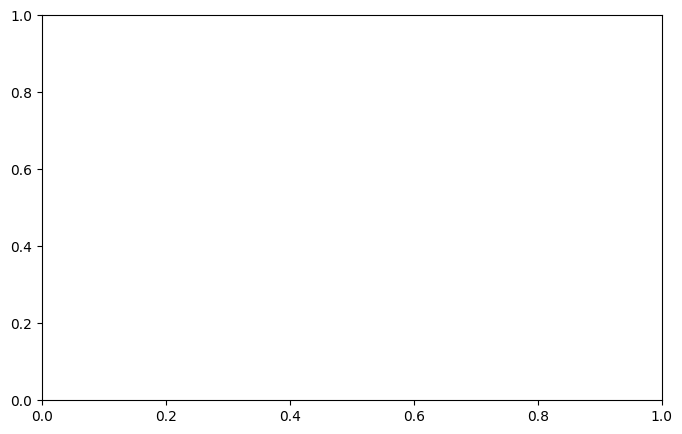

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
import os

# Ensure PATTERN_DIR is defined
if 'PATTERN_DIR' not in globals():
    PATTERN_DIR = os.path.join(OUTPUT_DIR, 'pattern')
    os.makedirs(PATTERN_DIR, exist_ok=True)

print('Generating individual learning curve plots...')

lc_models = {
    'Random Forest': (best_rf,       X_train, y_train),
    'XGBoost':       (xgb_for_stack, X_train, y_train),
    'SVM':           (svm_clf,       X_train, y_train),
    'Logistic Reg':  (lr_clf,        X_train, y_train),
    'Stacking':      (stack_clf,     X_train, y_train),
}
train_sizes = np.linspace(0.10, 1.0, 8)

for name, (clf, Xc, yc) in lc_models.items():
    fig, ax = plt.subplots(figsize=(8, 5))
    ts, tr_sc, val_sc = learning_curve(
        clf, Xc, yc,
        cv=cv5, train_sizes=train_sizes,
        scoring='accuracy', n_jobs=-1,
        shuffle=True, random_state=RANDOM_STATE
    )
    tr_m  = tr_sc.mean(axis=1); tr_s  = tr_sc.std(axis=1)
    val_m = val_sc.mean(axis=1); val_s = val_sc.std(axis=1)

    ax.plot(ts, tr_m,  'o-', color='#3498db', lw=2, label='Train')
    ax.fill_between(ts, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color='#3498db')
    ax.plot(ts, val_m, 's-', color='#e74c3c', lw=2, label='CV Val')
    ax.fill_between(ts, val_m-val_s, val_m+val_s, alpha=0.15, color='#e74c3c')
    ax.axhline(ACC_CAP, color='gray', linestyle='--', lw=1.2,
               label=f'{ACC_CAP:.0%} cap')
    ax.set_title(f'Learning Curve - {name}', fontweight='bold')
    ax.set_xlabel('Training samples'); ax.set_ylabel('Accuracy')
    ax.set_ylim(0.50, 1.02)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PATTERN_DIR}/learning_curve_{name.replace(' ', '_').lower()}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f'Individual learning curve plots saved to {PATTERN_DIR}')

### Separating and Saving Individual Overfit Diagnostic Dashboard Plots

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

# Ensure PATTERN_DIR is defined
if 'PATTERN_DIR' not in globals():
    PATTERN_DIR = os.path.join(OUTPUT_DIR, 'pattern')
    os.makedirs(PATTERN_DIR, exist_ok=True)

print('Generating individual Overfit Diagnostic Dashboard plots...')

names   = list(results.keys())
tr_accs = [results[n]['train_acc'] for n in names]
te_accs = [results[n]['test_acc']  for n in names]
gaps    = [results[n]['gap']       for n in names]
f1s     = [results[n]['f1']        for n in names]
rocs    = [results[n]['roc']       for n in names]
x = np.arange(len(names)); w = 0.38

# Panel 1 — Train vs Test accuracy
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.bar(x-w/2, tr_accs, width=w, label='Train', color='#3498db', alpha=0.85)
ax1.bar(x+w/2, te_accs, width=w, label='Test',  color='#e74c3c', alpha=0.85)
ax1.axhline(ACC_CAP, color='black', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax1.set_xticks(x); ax1.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax1.set_ylim(0.50, 1.02); ax1.set_ylabel('Accuracy')
ax1.set_title('Train vs Test Accuracy', fontweight='bold'); ax1.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel1_train_test_acc.png', dpi=150, bbox_inches='tight')
plt.close(fig1)

# Panel 2 — Overfit gap (must be positive & small)
fig2, ax2 = plt.subplots(figsize=(8, 6))
bar_cols = ['#e74c3c' if g > 0.05 or g < 0 else '#2ecc71' for g in gaps]
bars = ax2.bar(x, gaps, color=bar_cols, alpha=0.85)
ax2.axhline(0.05, color='gray', linestyle='--', lw=1.5, label='5% overfit threshold')
ax2.axhline(0,    color='black', linestyle='-',  lw=1.0)
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Train − Test Acc (gap)')
ax2.set_title('Overfitting Gap  (green = healthy positive)', fontweight='bold')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel2_overfit_gap.png', dpi=150, bbox_inches='tight')
plt.close(fig2)

# Panel 3 — F1 & ROC-AUC
fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.bar(x-w/2, f1s,  width=w, label='F1 (weighted)', color='#2ecc71', alpha=0.85)
ax3.bar(x+w/2, rocs, width=w, label='ROC-AUC',       color='#9b59b6', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax3.set_ylim(0.50, 1.02); ax3.set_ylabel('Score')
ax3.set_title('F1 & ROC-AUC  (Test Set)', fontweight='bold'); ax3.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel3_f1_roc_auc.png', dpi=150, bbox_inches='tight')
plt.close(fig3)

# Panel 4 — CV box plots
fig4, ax4 = plt.subplots(figsize=(8, 6))
bp = ax4.boxplot([cv_scores[k] for k in cv_scores],
                  labels=['RF','XGB','SVM','LR','Stack'],
                  patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax4.axhline(ACC_CAP, color='red', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax4.set_ylim(0.50, 1.02); ax4.set_ylabel('CV Accuracy')
ax4.set_title('5-Fold CV Distribution', fontweight='bold'); ax4.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel4_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.close(fig4)

# Panel 5 — XGB loss
fig5, ax5 = plt.subplots(figsize=(8, 6))
ax5.plot(range(1, len(train_loss)+1), train_loss, color='#3498db', lw=2, label='Train loss')
ax5.plot(range(1, len(val_loss)+1),   val_loss,   color='#e74c3c', lw=2, label='Val loss')
ax5.axvline(best_xgb.best_iteration, color='green', linestyle='--', lw=2,
             label=f'Stop @ {best_xgb.best_iteration}')
ax5.set_xlabel('Rounds'); ax5.set_ylabel('Log-loss')
ax5.set_title('XGBoost Early Stopping', fontweight='bold')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel5_xgb_loss.png', dpi=150, bbox_inches='tight')
plt.close(fig5)

# Panel 6 — RF incremental
fig6, ax6 = plt.subplots(figsize=(8, 6))
ax6.plot(rf_history['n_trees'], rf_history['train_acc'],
          'o-', color='#3498db', lw=2, label='Train')
ax6.plot(rf_history['n_trees'], rf_history['val_acc'],
          's-', color='#e74c3c', lw=2, label='Val')
ax6.axhline(ACC_CAP, color='gray', linestyle='--', lw=1.8, label=f'{ACC_CAP:.0%} cap')
ax6.set_xlabel('Trees'); ax6.set_ylabel('Accuracy')
ax6.set_title('RF Incremental  (Train > Val = healthy)',
              fontweight='bold')
ax6.set_ylim(0.50, 1.02); ax6.legend(fontsize=8); ax6.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PATTERN_DIR}/dashboard_panel6_rf_incremental.png', dpi=150, bbox_inches='tight')
plt.close(fig6)

print(f'Individual Overfit Diagnostic Dashboard plots saved to {PATTERN_DIR}')

Generating individual Overfit Diagnostic Dashboard plots...
Individual Overfit Diagnostic Dashboard plots saved to /content/outputs/pattern


In [ ]:
print('=' * 60)
print('STEP 1: Load & Clean')
print('=' * 60)

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

COL_MAP = {
    'PM2.5 (?g/m?)':'PM2_5','PM2.5':'PM2_5','pm2.5':'PM2_5','PM25':'PM2_5',
    'PM10 (?g/m?)':'PM10','pm10':'PM10',
    'CO2 (ppm)':'CO2','co2':'CO2',
    'TVOC (ppb)':'TVOC','tvoc':'TVOC',
    'CO (ppm)':'CO','co':'CO',
    'Temperature (?C)':'Temperature','temperature':'Temperature','temp':'Temperature',
    'Humidity (%)':'Humidity','humidity':'Humidity',
    'Light Intensity (lux)':'Light','light':'Light','light_intensity':'Light',
}
df.rename(columns={c: COL_MAP[c] for c in df.columns if c in COL_MAP}, inplace=True)

FEATURE_COLS = [c for c in
    ['PM2_5','PM10','CO2','TVOC','CO','Temperature','Humidity','Light']
    if c in df.columns]

df = df[FEATURE_COLS].copy()
df.dropna(inplace=True)
print(f'Shape    : {df.shape}')
print(f'Features : {FEATURE_COLS}')

STEP 1: Load & Clean
Shape    : (82909, 8)
Features : ['PM2_5', 'PM10', 'CO2', 'TVOC', 'CO', 'Temperature', 'Humidity', 'Light']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

# Ensure PATTERN_DIR is defined
if 'PATTERN_DIR' not in globals():
    PATTERN_DIR = os.path.join(OUTPUT_DIR, 'pattern')
    os.makedirs(PATTERN_DIR, exist_ok=True)

print('Generating individual confusion matrix plots...')

for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(
        f"{PATTERN_DIR}/cm_{name.replace(' ','_').lower()}.png",
        dpi=150, bbox_inches='tight')
    plt.close()

print(f'Individual confusion matrix plots saved to {PATTERN_DIR}')

Generating individual confusion matrix plots...
Individual confusion matrix plots saved to /content/outputs/pattern


In [ ]:
import os
import zipfile

folder_path = "/content/outputs"
zip_path = "output_new.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path, os.path.relpath(file_path, folder_path))

print("Folder zipped successfully!")

Folder zipped successfully!
